In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
class WindowDataset(Dataset):
    def __init__(self, _data, _window):
        # _data : tensor, array 1차원 데이터 형태
        # _window : 구간의 크기 
        self.data = _data
        self.window = _window
        # DataLoader에서 사용이 가능한 인덱스의 최대 값
        self.n = len(_data) - _window

    def __len__(self):
        return self.n
    
    def __getitem__(self, idx):
        # idx : 0 ~ self.n-1 사이의 정수가 대입 (DataLoader에서 자동으로 대입)
        x = self.data[idx:idx + self.window]
        y = self.data[idx + self.window]
        return x, y

In [3]:
# RNN 모델 정의 
class RNNModel(nn.Module):
    def __init__(self,
                 input_size, 
                 hidden_size = 64, 
                 num_layers = 1, 
                 dropout = 0.0, 
                 nonlinearity = 'tanh', 
                 bidirectional = False):
        super(RNNModel, self).__init__()
        # super().__init__()
        self.rnn = nn.RNN(
            input_size = input_size,
            hidden_size = hidden_size, 
            num_layers = num_layers, 
            dropout = dropout, 
            nonlinearity = nonlinearity, 
            bidirectional = bidirectional, 
            # batch_first는 기본이 Fasle였던걸 까먹고 안 넣고 있었네요 
            # 죄송합니다. 
            # batch_first가 False인 경우, 입력 데이터(구간의 개수, 배치크기, 입력 데이터 피쳐의 수)
            # (배치 크기, 구간의 크기, 입력 피쳐의 개수) --> True로 변경 
            batch_first = True
        )

        # output_feature가 역방향을 포함한다면 2배로 늘어난다. 
        if bidirectional:
            hidden_size *= 2
        print(f"hidden_size : {hidden_size}")
        self.model = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, h_n = self.rnn(x)
        last_hidden = h_n[-1]
        result = self.model(last_hidden)
        return result

In [4]:
# 모델 학습 시 검증 데이터를 이용하여 모델의 성능을 평가 할수 있도록 검증 데이터 평가 함수 

@torch.no_grad()
def evaluate_mse(dataloader, model):
    # dataloader -> 검증 데이터셋의 dataloader
    model.eval()
    total_loss = 0
    total_n = 0
    for x, y in dataloader:
        x = x.float()
        y = y.float()
        pred = model(x)
        loss = nn.MSELoss()(pred, y)
        # total_loss에서도 +=을 +로만 쓰는 막대한 실수를 했네요 
        total_loss += loss.item() * x.size(0)
        total_n += x.size(0)
    return total_loss / max(total_n, 1)

In [5]:
df = pd.read_csv("../csv/aapl.csv")
df.info()
df.dropna(inplace=True)

df = df[['Date', 'Adj Close']]
values = df[['Adj Close']].values

df['Adj Close'].values.reshape(-1, 1)

split_idx = int(len(values) * 0.75)

train_data = values[:split_idx]
test_data = values[split_idx:]

<class 'pandas.DataFrame'>
RangeIndex: 9715 entries, 0 to 9714
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9715 non-null   str    
 1   Open       9714 non-null   float64
 2   High       9714 non-null   float64
 3   Low        9714 non-null   float64
 4   Close      9714 non-null   float64
 5   Adj Close  9714 non-null   float64
 6   Volume     9713 non-null   float64
dtypes: float64(6), str(1)
memory usage: 531.4 KB


In [ ]:
# MinMaxScaler로 데이터 정규화
scaler = MinMaxScaler()
train_sc = scaler.fit_transform(train_data)
test_sc = scaler.transform(test_data)

# 스케일링이 완료된 데이터를 Tensor로 변환 
train_sc = torch.tensor(train_sc, dtype=torch.float32)
test_sc = torch.tensor(test_sc, dtype=torch.float32)

# WindowDataset에 데이터를 대입 
train_ds = WindowDataset(train_sc, _window=60)
test_ds = WindowDataset(test_sc, _window=60)

# Dataset를 DataLoader로 생성 
train_dl = DataLoader(train_ds, batch_size=128, shuffle = True, drop_last = True)
test_dl = DataLoader(test_ds, batch_size=256, shuffle=False, drop_last = False)

aapl_model = RNNModel(
    input_size = 1, 
    hidden_size = 128
)
criterion = nn.MSELoss()
optimizer = optim.Adam(aapl_model.parameters(), lr = 0.001)

hidden_size : 128


In [7]:
# 모델 학습 
train_history, test_history = [], []
for epoch in range(20):
    aapl_model.train()
    running, n_seen = 0.0, 0
    for x, y in train_dl:
        x = x.float()
        y = y.float()
        pred = aapl_model(x)
        loss = criterion(pred, y)
        # print(x.shape, y.shape)
        # print(pred.shape, y.shape)
        # break
        optimizer.zero_grad()
        loss.backward()
        # 가중치 발산 방지 
        nn.utils.clip_grad_norm_(aapl_model.parameters(), 1.0)
        optimizer.step()

        running += loss.item() * y.size(0)
        n_seen += y.size(0)
    train_mse = running / n_seen
    test_mse = evaluate_mse(test_dl, aapl_model)
    train_history.append(train_mse)
    test_history.append(test_mse)
    print(f"Epoch {epoch+1} Train MSE: {round(train_mse, 8)} Test MSE: {round(test_mse, 8)}")

Epoch 1 Train MSE: 0.00515536 Test MSE: 4.40203502
Epoch 2 Train MSE: 0.00011091 Test MSE: 4.03160157
Epoch 3 Train MSE: 0.00010533 Test MSE: 3.87017505
Epoch 4 Train MSE: 8.806e-05 Test MSE: 3.709903
Epoch 5 Train MSE: 8.583e-05 Test MSE: 3.53511637
Epoch 6 Train MSE: 9.079e-05 Test MSE: 3.32748812
Epoch 7 Train MSE: 8.546e-05 Test MSE: 3.26426677
Epoch 8 Train MSE: 9.022e-05 Test MSE: 3.09451714
Epoch 9 Train MSE: 8.173e-05 Test MSE: 2.97313277
Epoch 10 Train MSE: 7.813e-05 Test MSE: 2.8543488
Epoch 11 Train MSE: 7.59e-05 Test MSE: 2.72121333
Epoch 12 Train MSE: 7.827e-05 Test MSE: 2.70645132
Epoch 13 Train MSE: 7.761e-05 Test MSE: 2.5683293
Epoch 14 Train MSE: 7.679e-05 Test MSE: 2.52575106
Epoch 15 Train MSE: 8.59e-05 Test MSE: 2.41236414
Epoch 16 Train MSE: 8.48e-05 Test MSE: 2.32769537
Epoch 17 Train MSE: 7.176e-05 Test MSE: 2.33602602
Epoch 18 Train MSE: 7.5e-05 Test MSE: 2.28518015
Epoch 19 Train MSE: 7.645e-05 Test MSE: 2.21942578
Epoch 20 Train MSE: 7.509e-05 Test MSE: 2.1118

In [8]:
# 학습 된 모델을 이용하여 예측 값을 확인하고 실젯값과의 차이를 그래프로 시각화
aapl_model.eval()

preds = []
trues = []

with torch.no_grad():
    for x, y in test_dl:
        x = x.float()
        y = y.float()

        pred = aapl_model(x)
        preds.append(pred.cpu())
        trues.append(y.cpu())

In [9]:
preds = torch.cat(preds, dim=0).squeeze(-1).numpy()
trues = torch.cat(trues, dim=0).squeeze(-1).numpy()

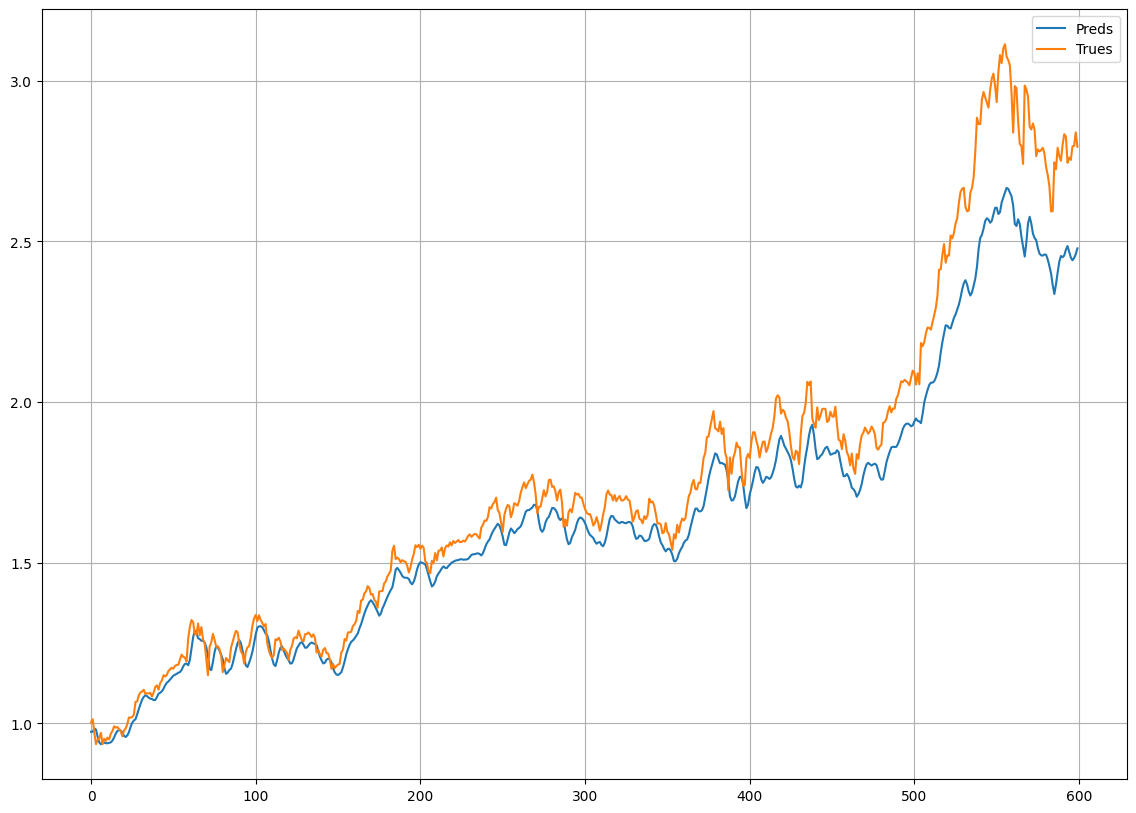

In [10]:
plt.figure(figsize = (14, 10))
plt.plot(preds[:600], label = 'Preds')
plt.plot(trues[:600], label = 'Trues')
plt.legend()
plt.grid()
plt.show()